In [1]:
from pathlib import Path
from pydoc import describe

import nibabel as nib
import pandas as pd

from resources.find_centre import find_centre
from resources.find_pitch_error_y_y import find_pitch_error

from resources.cut_off_edges import cut_off_edges
from resources.find_rotation_error import find_rotation_error, find_rotation_error_by_profile
from resources.rotate_image import rotate_volume
from resources.find_tilt_error import find_tilt_error, find_tilt_error_by_profile
from resources.standarize_image import standardize_image

In [2]:
project_dir = Path.cwd().resolve().parents[2]
# print(project_dir)
niftis_dir = project_dir / "data" / "niftis"
outputs_dir = project_dir / "src" / "outputs" / "cut_images"

outputs_dir.mkdir(parents=True, exist_ok=True)

nifti_paths = sorted(niftis_dir.glob("*.nii.gz"))
labels_path = niftis_dir / "train_labels_JNDlMjr.csv"
labels = pd.read_csv(labels_path)


In [3]:
results = []

for index, nifti_path in enumerate(nifti_paths[0:500], start=1):
    # Odczyt obrazu jako obiekt NIfTI
        image = nib.load(nifti_path)

        # Obróbka obrazu; funkcja zwraca obiekt NIfTI
        processed_image = cut_off_edges(image)
        processed_image = cut_off_edges(processed_image,x_left=35,x_right=35,y_front=40,y_back=40,z_down=30,z_up=30)
        processed_image = cut_off_edges(processed_image, x_left=30, x_right=30, y_front=30, y_back=30, z_down=20, z_up=25)

        # # względnie rotation przetestowane musi bazować na minimum w osi obrotu w około z na 180 jest ok dla minimum
        # # tilt error dla maksimum z rotation profile w różnicy od 90 jest ok

        # rotation_error = find_rotation_error(processed_image)

        # x_centre, y_centre, z_centre = find_centre(processed_image)
        # processed_image = cut_off_edges(processed_image, x_left=25, x_right=25, y_front=25, y_back=25, z_down=20, z_up=20)
        # Standaryzacja obrazu
        # processed_image = standardize_image(processed_image, percent_top=0.02)
        rotation_error = find_rotation_error_by_profile(processed_image)
        tilt_error = find_tilt_error_by_profile(processed_image)
        pitch_error = None
        #

        # rotation_error = None

        # tilt_error = None
        # pitch_error = find_pitch_error(processed_image)


        uid = Path(nifti_path).name.replace(".nii.gz", "")

        pathological = labels.loc[
            labels["uid"] == uid,
            "is_pathologic"
        ].iloc[0]

        results.append({
            "uid": uid,
            "pathological": pathological,
            "rotation_error": rotation_error,
            "tilt_error": tilt_error,
            "pitch_error": pitch_error
        })

        errors_df = pd.DataFrame(results)
        print(index)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [4]:
errors_df.describe()

,pathological,rotation_error,tilt_error
count,500.000000,500.000000,500.000000
mean,0.544000,-0.174000,-0.794000
std,0.498559,8.230626,7.090848
min,0.000000,-36.000000,-30.000000
25%,0.000000,-5.000000,-4.000000
50%,1.000000,0.000000,-0.500000
75%,1.000000,4.000000,2.000000
max,1.000000,35.000000,30.000000


In [5]:
errors_df[(errors_df["rotation_error"] == 12)]

,uid,pathological,rotation_error,tilt_error,pitch_error
48,15ahdbvz,0.0,12,2,None
58,1epxu7b6,0.0,12,1,None
119,344mw04i,1.0,12,-6,None
142,3obyghgk,1.0,12,-2,None
167,4a3yjtu7,1.0,12,7,None
199,513bb6f0,0.0,12,-2,None
260,6rv9777t,0.0,12,-1,None
353,9jrd4hqf,1.0,12,9,None
373,a0mvf4s2,1.0,12,8,None
385,ahulwjti,0.0,12,4,None


In [6]:
errors_df[(errors_df["tilt_error"] == -17)]

,uid,pathological,rotation_error,tilt_error,pitch_error
38,0vtkrrvw,1.0,-6,-17,None


In [7]:
# max_error = errors_df["rotation_error"].max()

errors_df[(errors_df["rotation_error"] == 0) & (errors_df["tilt_error"] == 1)]

,uid,pathological,rotation_error,tilt_error,pitch_error
221,5iz31yru,0.0,0,1,None
342,94xfri09,0.0,0,1,None
454,cd5glqj5,1.0,0,1,None


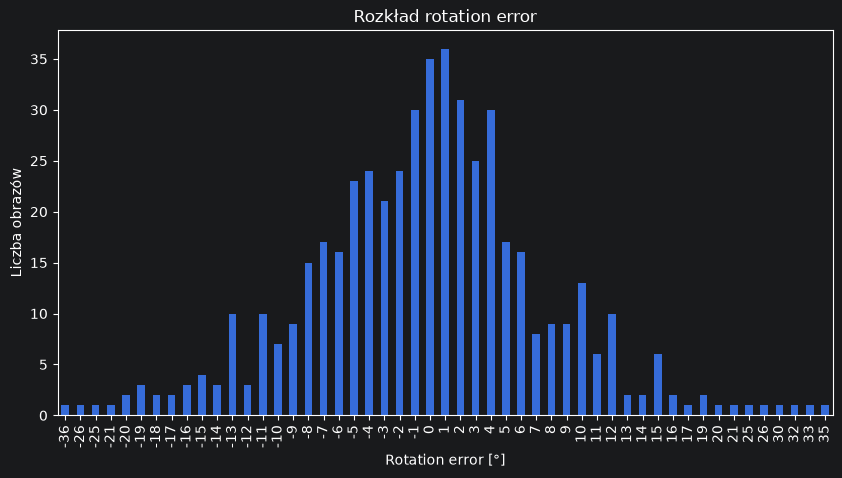

In [8]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 5))

errors_df["rotation_error"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Rotation error [°]")
plt.ylabel("Liczba obrazów")
plt.title("Rozkład rotation error")
plt.show()

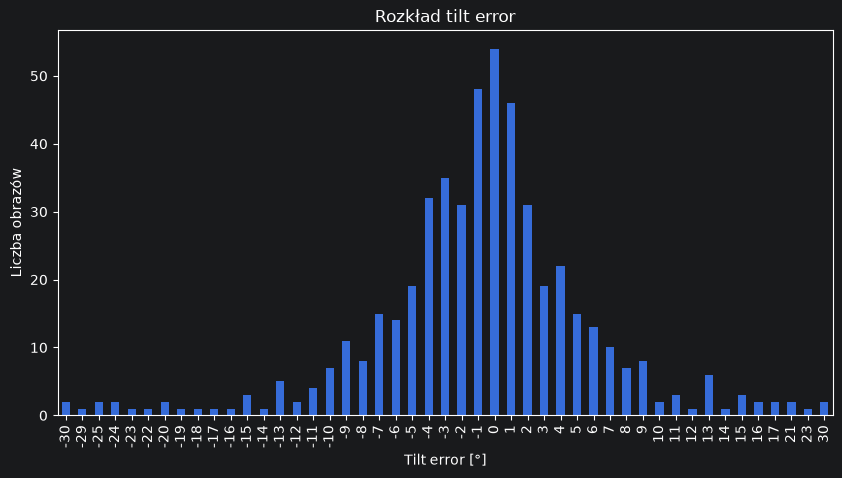

In [9]:
plt.figure(figsize=(10, 5))

errors_df["tilt_error"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Tilt error [°]")
plt.ylabel("Liczba obrazów")
plt.title("Rozkład tilt error")
plt.show()